In [1]:
import scanpy as sc
import harmonypy as hm
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/1588021508.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, frameon=False)


## Load and subset

In [2]:
adata = sc.read_h5ad('inputs/anndatas/omentum_reannotated_finely.h5ad')
adata

AnnData object with n_obs × n_vars = 25830 × 26158
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant'
    v

In [3]:
cell_types_keep = ['FAPs', 'Mesothelial', 'IGFBP2_cells', 'Pre_adipocytes']
sub = adata[adata.obs['cell_type_'].isin(cell_types_keep)].copy()
print(sub.obs['cell_type_'].value_counts())
sub

cell_type_
FAPs              6787
Mesothelial       5009
Pre_adipocytes    1297
IGFBP2_cells       587
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 13680 × 26158
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant'
    v

## Preprocess from raw counts

In [4]:
# Work from raw counts
sub.X = sub.layers['counts'].copy()

sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

sc.pp.highly_variable_genes(sub, n_top_genes=3000, flavor='seurat_v3', layer='counts')
print(f"Highly variable genes: {sub.var.highly_variable.sum()}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Highly variable genes: 3000


## PCA

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/923036363.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(sub, n_comps=15, use_highly_variable=True)


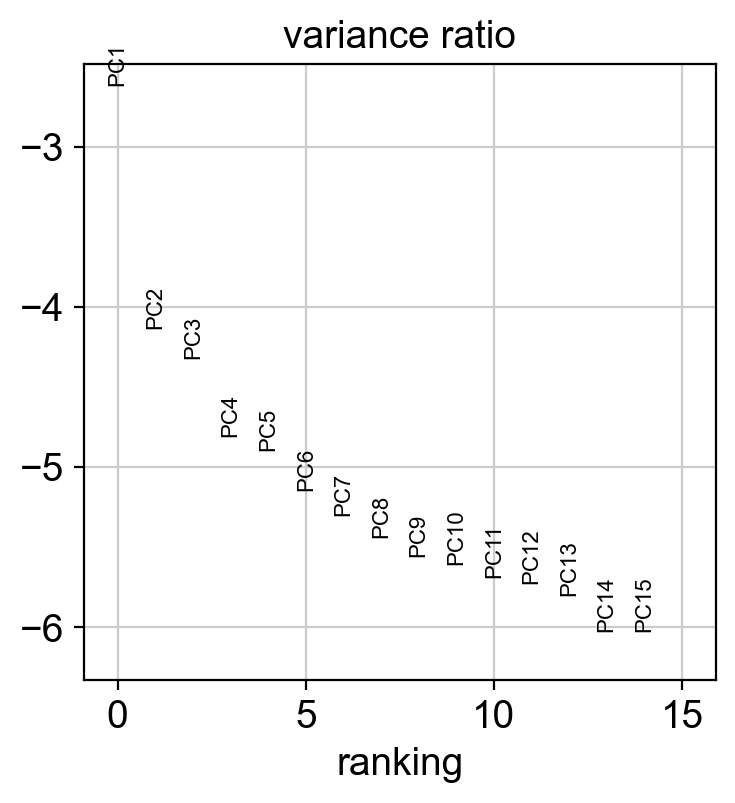

In [6]:
sc.pp.scale(sub, max_value=10)
sc.tl.pca(sub, n_comps=15, mask_var="highly_variable")
sc.pl.pca_variance_ratio(sub, n_pcs=15, log=True)

## Harmony integration on `common_participant`

In [10]:
ho = hm.run_harmony(
    sub.obsm['X_pca'],
    sub.obs,
    vars_use='common_participant',
    max_iter_harmony=30,
    random_state=42
)
sub.obsm['X_pca_harmony'] = ho.Z_corr
print('Harmony done, shape:', sub.obsm['X_pca_harmony'].shape)

2026-05-10 16:16:18,354 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-05-10 16:16:18,355 - harmonypy - INFO -   Parameters:
2026-05-10 16:16:18,355 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-10 16:16:18,355 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-10 16:16:18,356 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-10 16:16:18,357 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-10 16:16:18,358 - harmonypy - INFO -     nclust: 100
2026-05-10 16:16:18,358 - harmonypy - INFO -     block_size: 0.05
2026-05-10 16:16:18,360 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-10 16:16:18,361 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-10 16:16:18,363 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-10 16:16:18,364 - harmonypy - INFO -     verbose: True
2026-05-10 16:16:18,365 - harmonypy - INFO -     random_state: 42
2026-05-10 16:16:18,366 - harmonypy - INFO -   Data: 15 PCs × 13680

Harmony done, shape: (13680, 15)


## Neighbor graph, Leiden clustering, and UMAP

In [21]:
sc.pp.neighbors(sub, use_rep='X_pca', n_neighbors=10, n_pcs=15) # _harmony
sc.tl.leiden(sub, resolution=0.4, key_added='leiden')
sc.tl.umap(sub, min_dist=0.3, random_state=42)

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/870776056.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(sub, resolution=0.4, key_added='leiden')


## UMAP plots

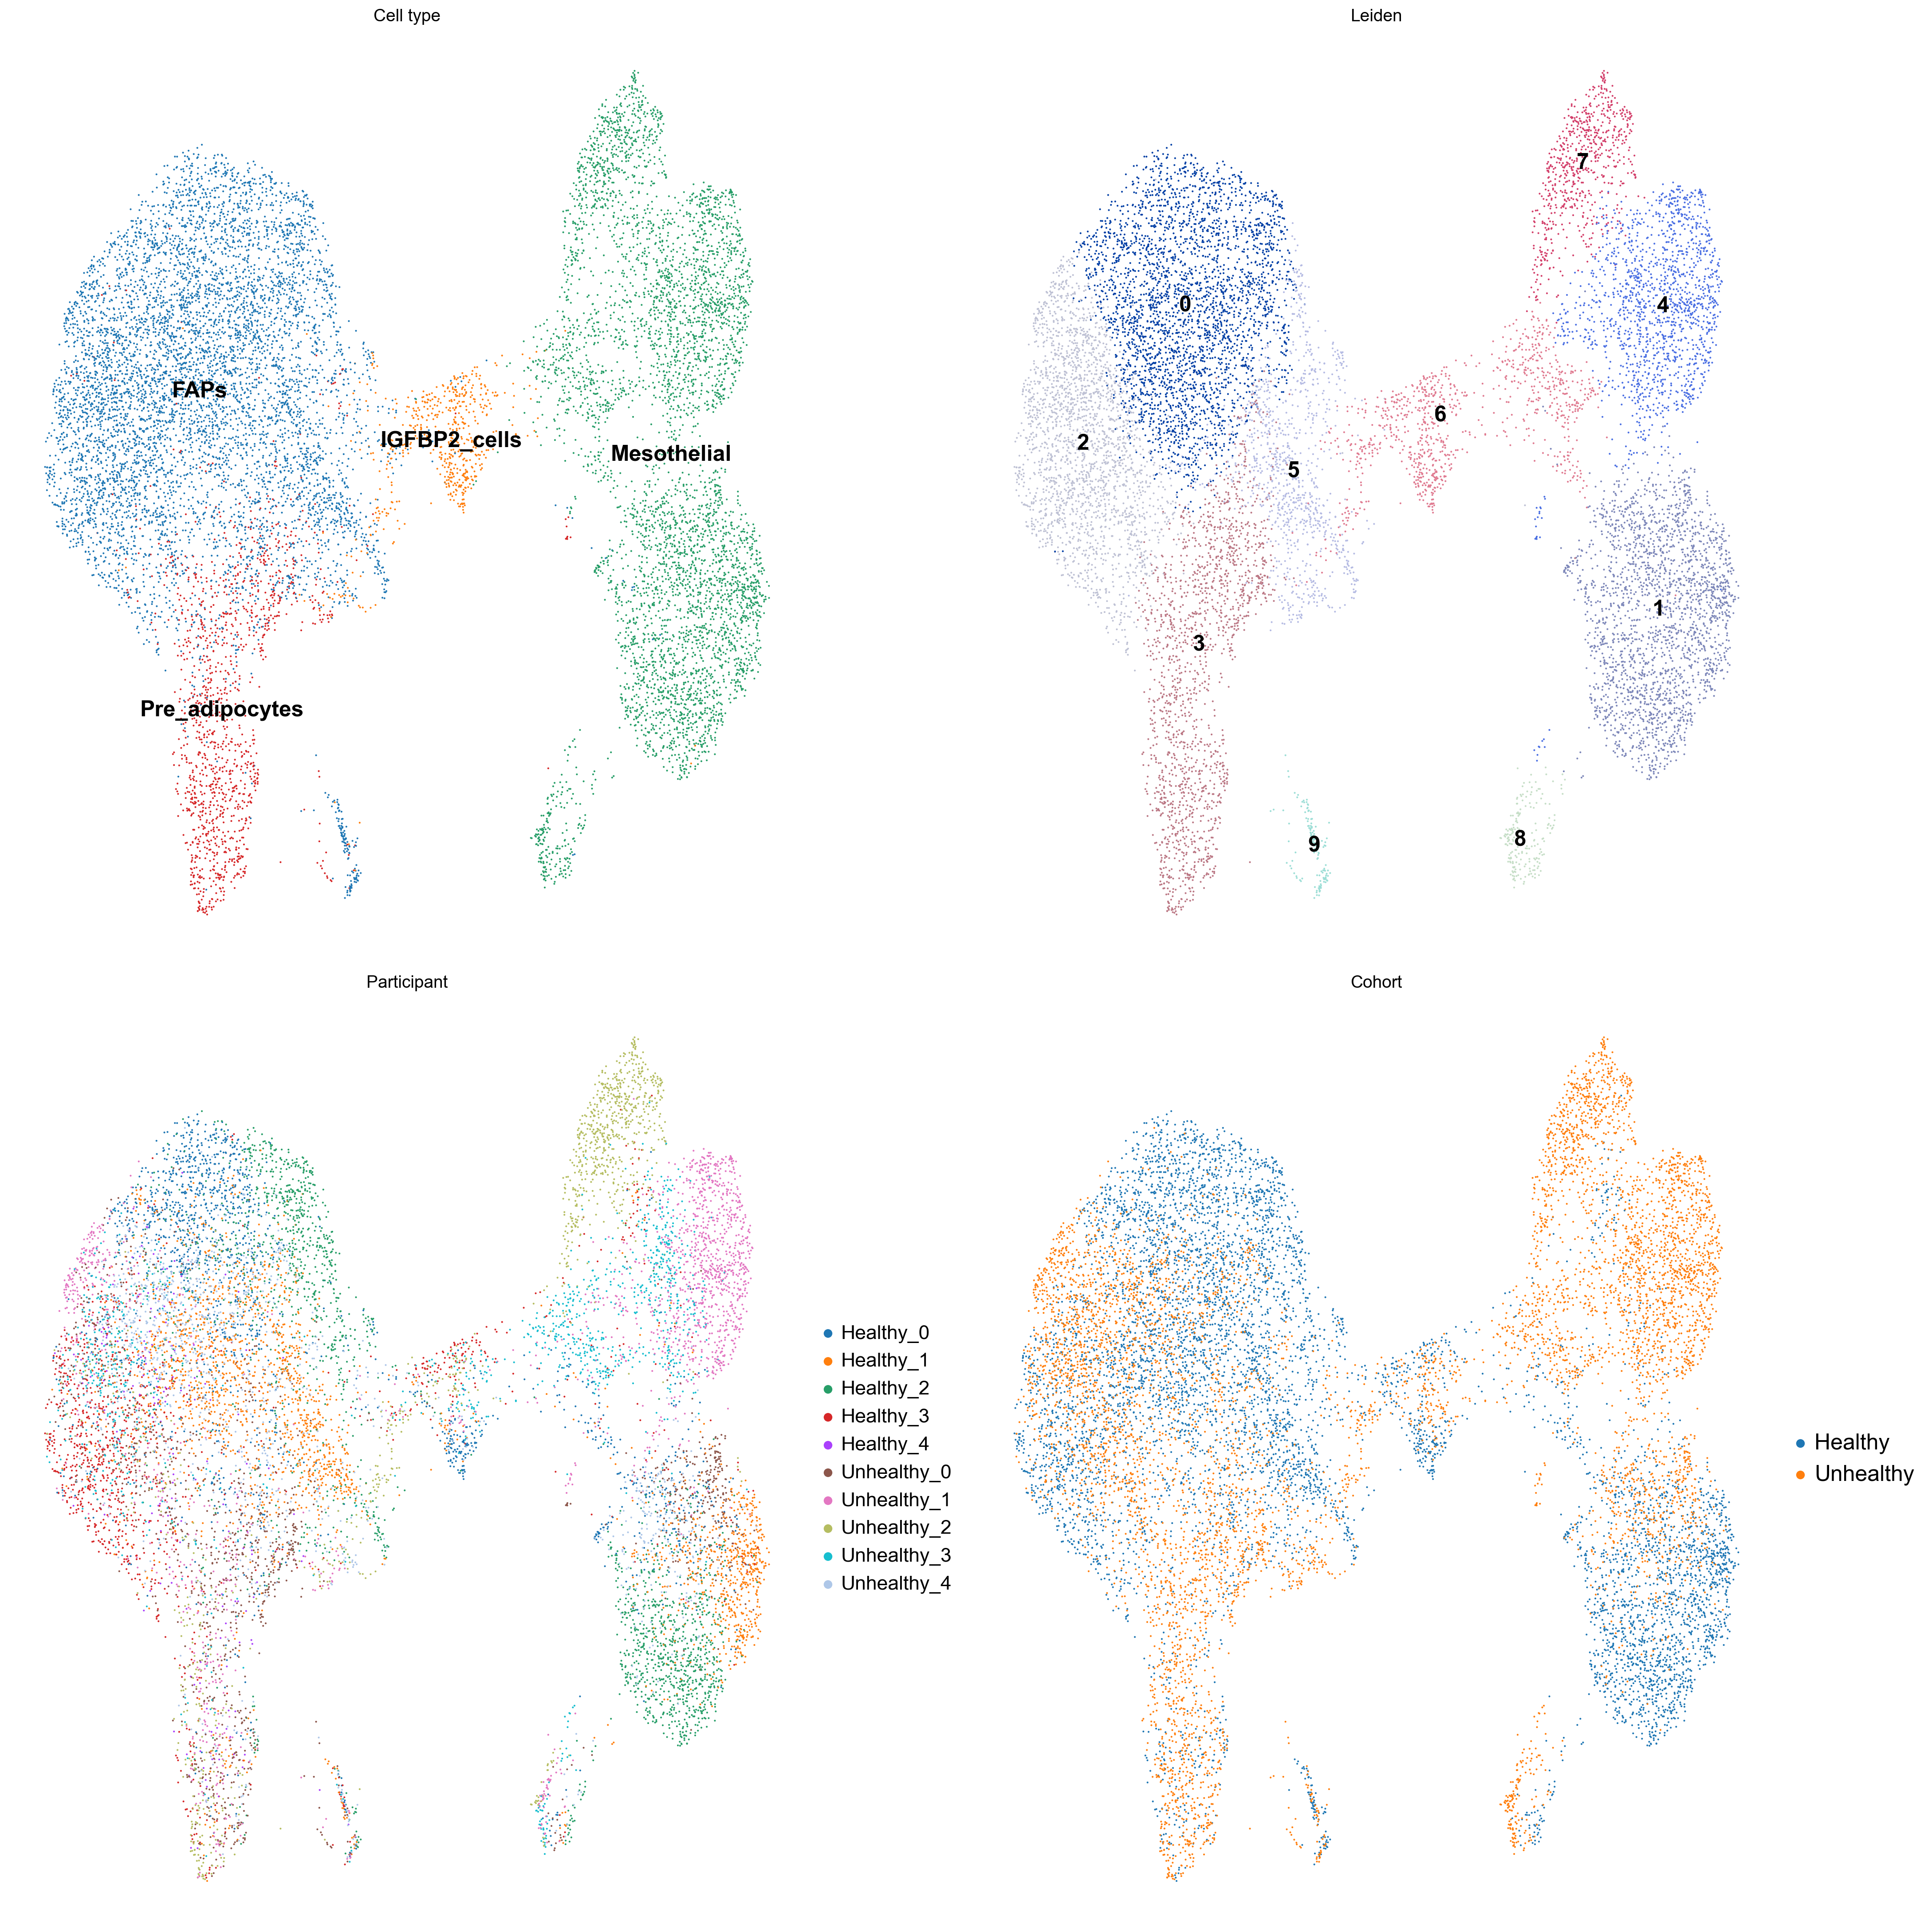

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(22, 22))

sc.pl.umap(sub, color='cell_type_',      title='Cell type',          ax=axes[0, 0], show=False, legend_loc='on data', legend_fontsize=18)
sc.pl.umap(sub, color='leiden',  title='Leiden',   ax=axes[0, 1], show=False, legend_loc='on data', legend_fontsize=18)
sc.pl.umap(sub, color='common_participant', title='Participant',      ax=axes[1, 0], show=False, legend_fontsize=16)
sc.pl.umap(sub, color='cohort',          title='Cohort',             ax=axes[1, 1], show=False, legend_fontsize=18)

plt.tight_layout()
plt.savefig('figures/stromal_harmony_umap.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/1895049372.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.obs.groupby(['leiden', 'cohort'])


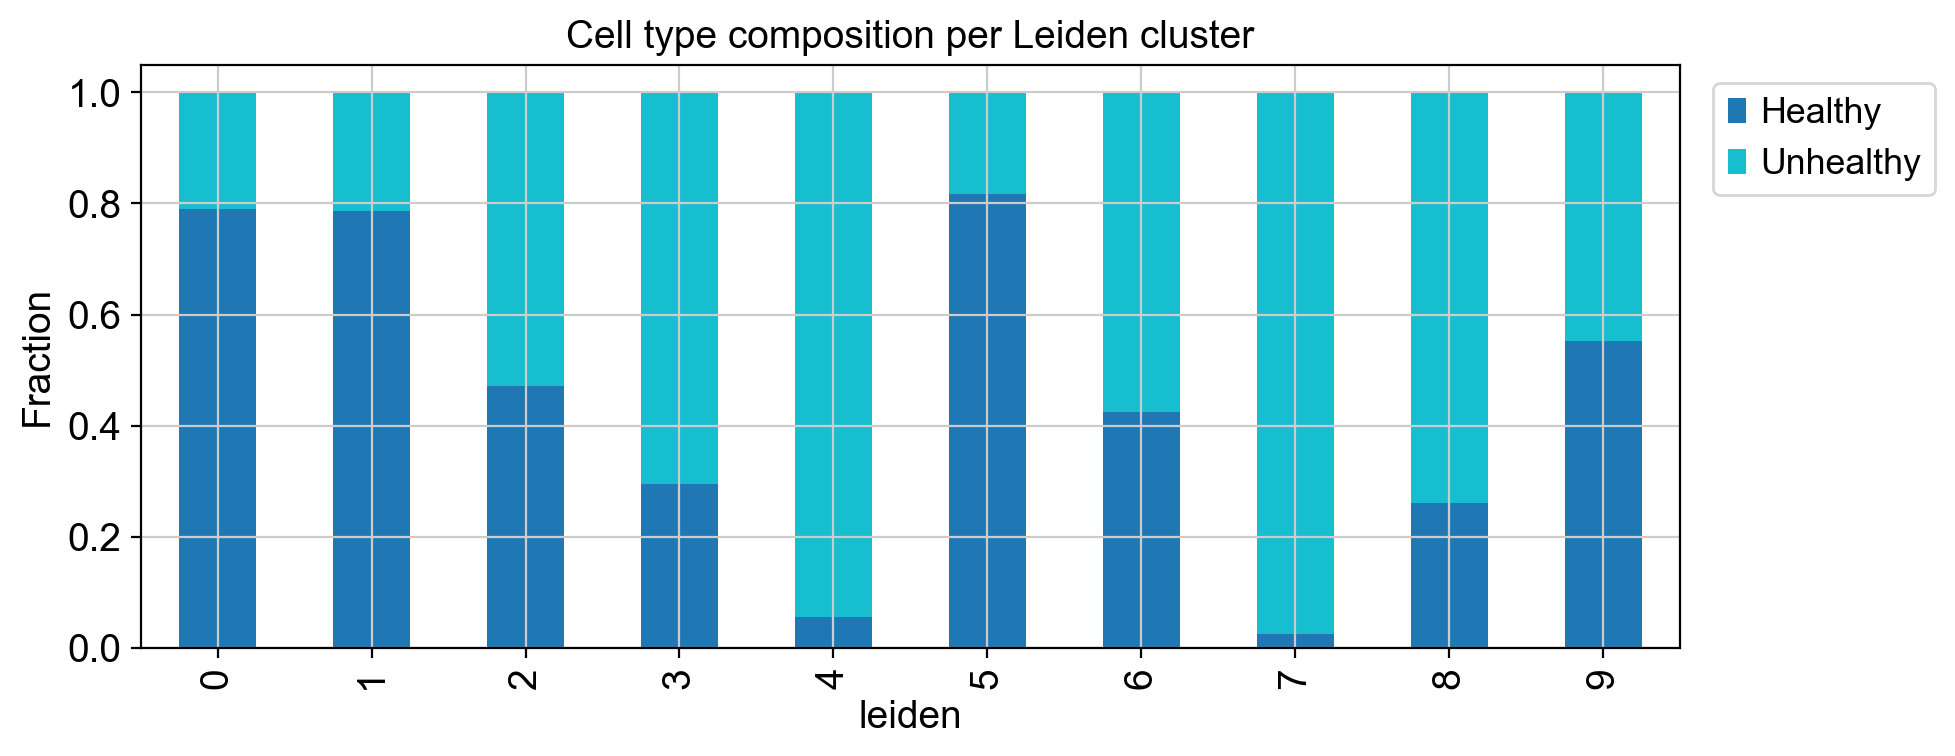

In [23]:
# Cluster composition
cluster_ct = (
    sub.obs.groupby(['leiden', 'cohort'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
cluster_ct.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab10')
plt.ylabel('Fraction')
plt.title('Cell type composition per Leiden cluster')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figures/stromal_harmony_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print(sub.obs['leiden_harmony'].value_counts().sort_index())

leiden_harmony
0    4116
1    3129
2    2872
3    1023
4     900
5     659
6     576
7     206
8     153
9      46
Name: count, dtype: int64


## DE: clusters 4+7 vs cluster 1

In [25]:
# Work from raw counts
sub.X = sub.layers['counts'].copy()

sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

In [26]:
# Label cells for comparison: clusters 4+7 combined vs cluster 1
mask_47 = sub.obs['leiden'].isin(['4', '7'])
mask_1  = sub.obs['leiden'] == '1'

sub_de1 = sub[mask_47 | mask_1].copy()
sub_de1.obs['de_group'] = sub_de1.obs['leiden'].map(
    lambda x: '4_7' if x in ('4', '7') else '1'
)
print(sub_de1.obs['de_group'].value_counts())

de_group
1      2264
4_7    2203
Name: count, dtype: int64


In [27]:
sc.tl.rank_genes_groups(
    sub_de1,
    groupby='de_group',
    groups=['4_7'],
    reference='1',
    method='wilcoxon',
    key_added='de_4_7_vs_1',
    pts=True,
)

de_4_7_vs_1 = sc.get.rank_genes_groups_df(
    sub_de1, group='4_7', key='de_4_7_vs_1'
).sort_values('scores', ascending=False)

print('Top upregulated in 4+7:')
print(de_4_7_vs_1.head(20).to_string(index=False))
print()
print('Top downregulated in 4+7 (= upregulated in 1):')
print(de_4_7_vs_1.tail(20).to_string(index=False))

Top upregulated in 4+7:
 names    scores  logfoldchanges         pvals     pvals_adj  pct_nz_group
 TXNIP 50.334232        3.499327  0.000000e+00  0.000000e+00      0.982751
 RPL10 39.570824        0.656344  0.000000e+00  0.000000e+00      1.000000
   FOS 39.178364        2.163918  0.000000e+00  0.000000e+00      0.996369
 RPL41 38.542782        0.656718  0.000000e+00  0.000000e+00      0.999546
  RPS9 36.538361        0.672941 2.729483e-292 6.226135e-289      0.998638
EEF1A1 36.537117        0.508967 2.856244e-292 6.226135e-289      1.000000
 RPS3A 35.213226        0.585178 1.254636e-271 2.187918e-268      0.999546
RPL10A 35.009869        0.725093 1.592281e-268 2.603180e-265      0.998638
 RACK1 33.531242        0.602487 1.689808e-246 2.009182e-243      0.999092
 GSTM3 33.108223        1.559181 2.263179e-240 2.573923e-237      0.940536
 RPL13 32.957073        0.420193 3.350109e-238 3.651340e-235      1.000000
 RPS10 32.235943        1.100446 5.537546e-228 4.994866e-225      0.978665
 

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/1565664294.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_dotplot(


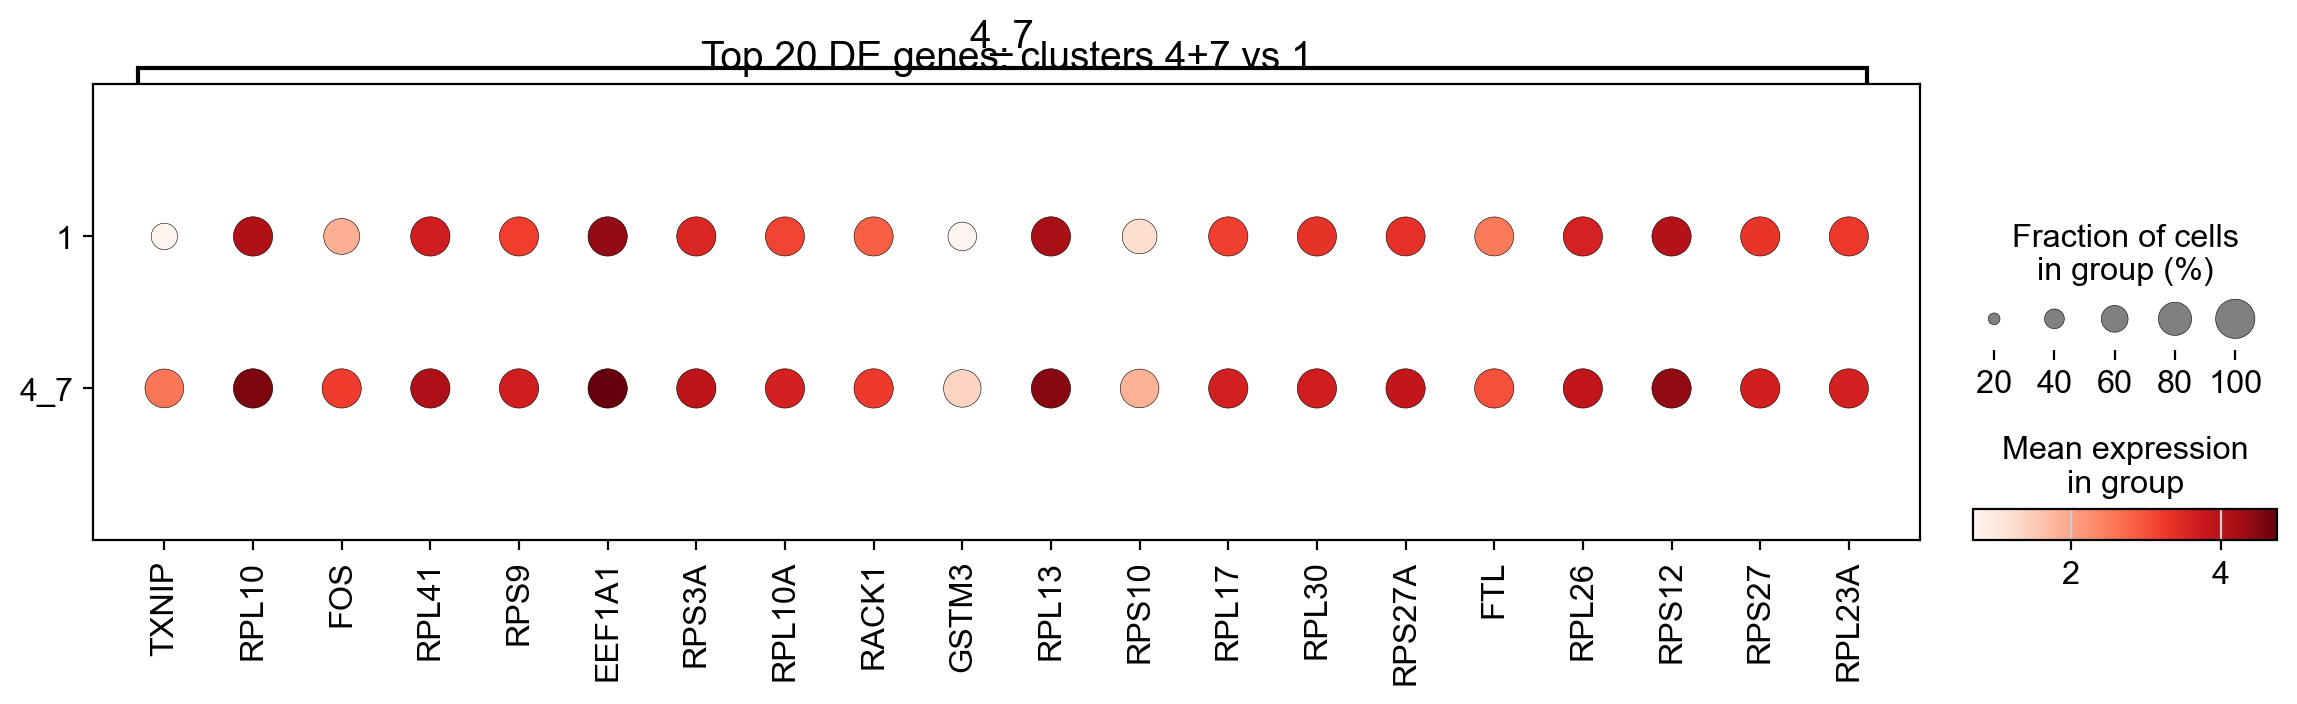

In [28]:
sc.pl.rank_genes_groups_dotplot(
    sub_de1,
    groupby='de_group',
    key='de_4_7_vs_1',
    n_genes=20,
    title='Top 20 DE genes: clusters 4+7 vs 1',
    figsize=(14, 3),
    save='_de_4_7_vs_1.png',
)

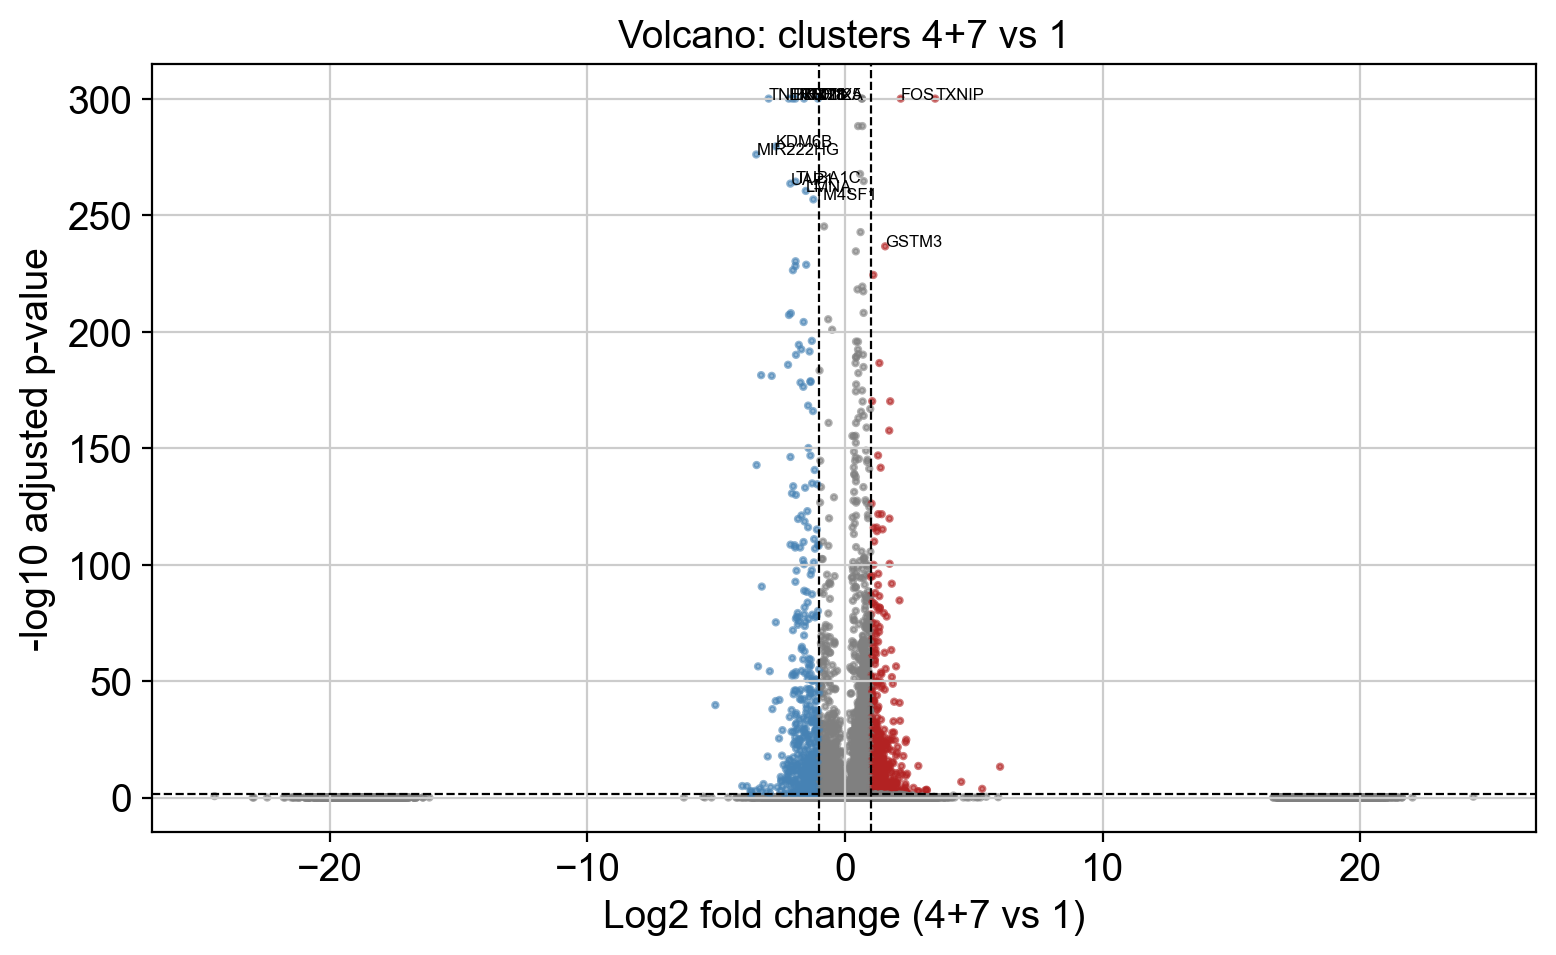

In [29]:
import numpy as np

df = de_4_7_vs_1.copy()
df['neg_log10_pval'] = -np.log10(df['pvals_adj'].clip(1e-300))
df['color'] = 'grey'
df.loc[(df['pvals_adj'] < 0.05) & (df['logfoldchanges'] >  1), 'color'] = 'firebrick'
df.loc[(df['pvals_adj'] < 0.05) & (df['logfoldchanges'] < -1), 'color'] = 'steelblue'

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['logfoldchanges'], df['neg_log10_pval'], c=df['color'], s=4, alpha=0.6)

for _, row in df[df['color'] != 'grey'].nlargest(15, 'neg_log10_pval').iterrows():
    ax.text(row['logfoldchanges'], row['neg_log10_pval'], row['names'], fontsize=6)

ax.axhline(-np.log10(0.05), color='k', lw=0.8, ls='--')
ax.axvline(1,  color='k', lw=0.8, ls='--')
ax.axvline(-1, color='k', lw=0.8, ls='--')
ax.set_xlabel('Log2 fold change (4+7 vs 1)')
ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano: clusters 4+7 vs 1')
plt.tight_layout()
plt.savefig('figures/volcano_de_4_7_vs_1.png', dpi=150, bbox_inches='tight')
plt.show()

## DE within cluster 8: Healthy vs Unhealthy

In [35]:
sub_c8 = sub[sub.obs['leiden'] == '8'].copy()
print(f"Cluster 8 cells: {sub_c8.n_obs}")
print(sub_c8.obs.value_counts(['cohort', "common_participant"]))

Cluster 8 cells: 200
cohort     common_participant
Unhealthy  Unhealthy_1           47
           Unhealthy_3           43
Healthy    Healthy_2             30
Unhealthy  Unhealthy_2           29
           Unhealthy_0           18
Healthy    Healthy_0             12
Unhealthy  Unhealthy_4           11
Healthy    Healthy_1              7
           Healthy_3              3
Name: count, dtype: int64


In [31]:
sc.tl.rank_genes_groups(
    sub_c8,
    groupby='cohort',
    groups=['Healthy'],
    reference='Unhealthy',
    method='wilcoxon',
    key_added='de_c8_healthy_vs_unhealthy',
    pts=True,
)

de_c8 = sc.get.rank_genes_groups_df(
    sub_c8, group='Healthy', key='de_c8_healthy_vs_unhealthy'
).sort_values('scores', ascending=False)

print('Top upregulated in Healthy (cluster 8):')
print(de_c8.head(20).to_string(index=False))
print()
print('Top downregulated in Healthy / upregulated in Unhealthy (cluster 8):')
print(de_c8.tail(20).to_string(index=False))

Top upregulated in Healthy (cluster 8):
    names   scores  logfoldchanges        pvals    pvals_adj  pct_nz_group
    NEAT1 7.534030        1.522209 4.919789e-14 6.434592e-10      1.000000
   S100A6 6.801516        0.820121 1.035239e-11 4.513297e-08      1.000000
   ERRFI1 6.489571        1.685259 8.608115e-11 2.814639e-07      1.000000
     CD55 6.463111        1.732550 1.025718e-10 2.981191e-07      0.980769
TNFRSF12A 6.062039        1.759279 1.344065e-09 2.068121e-06      0.903846
    MAT2A 6.042542        1.533827 1.517043e-09 2.204601e-06      0.903846
     UAP1 5.936704        1.766132 2.908089e-09 3.622371e-06      0.903846
    DDX21 5.786302        1.384761 7.195280e-09 7.528566e-06      0.942308
    IL1R1 5.741738        1.502647 9.370950e-09 8.522404e-06      0.826923
    FOSL1 5.679071        2.537884 1.354283e-08 1.142753e-05      0.692308
     SDC4 5.665145        1.652530 1.469004e-08 1.200819e-05      0.807692
  GADD45A 5.615011        1.402953 1.965500e-08 1.428154e-05

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/1685991407.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_dotplot(


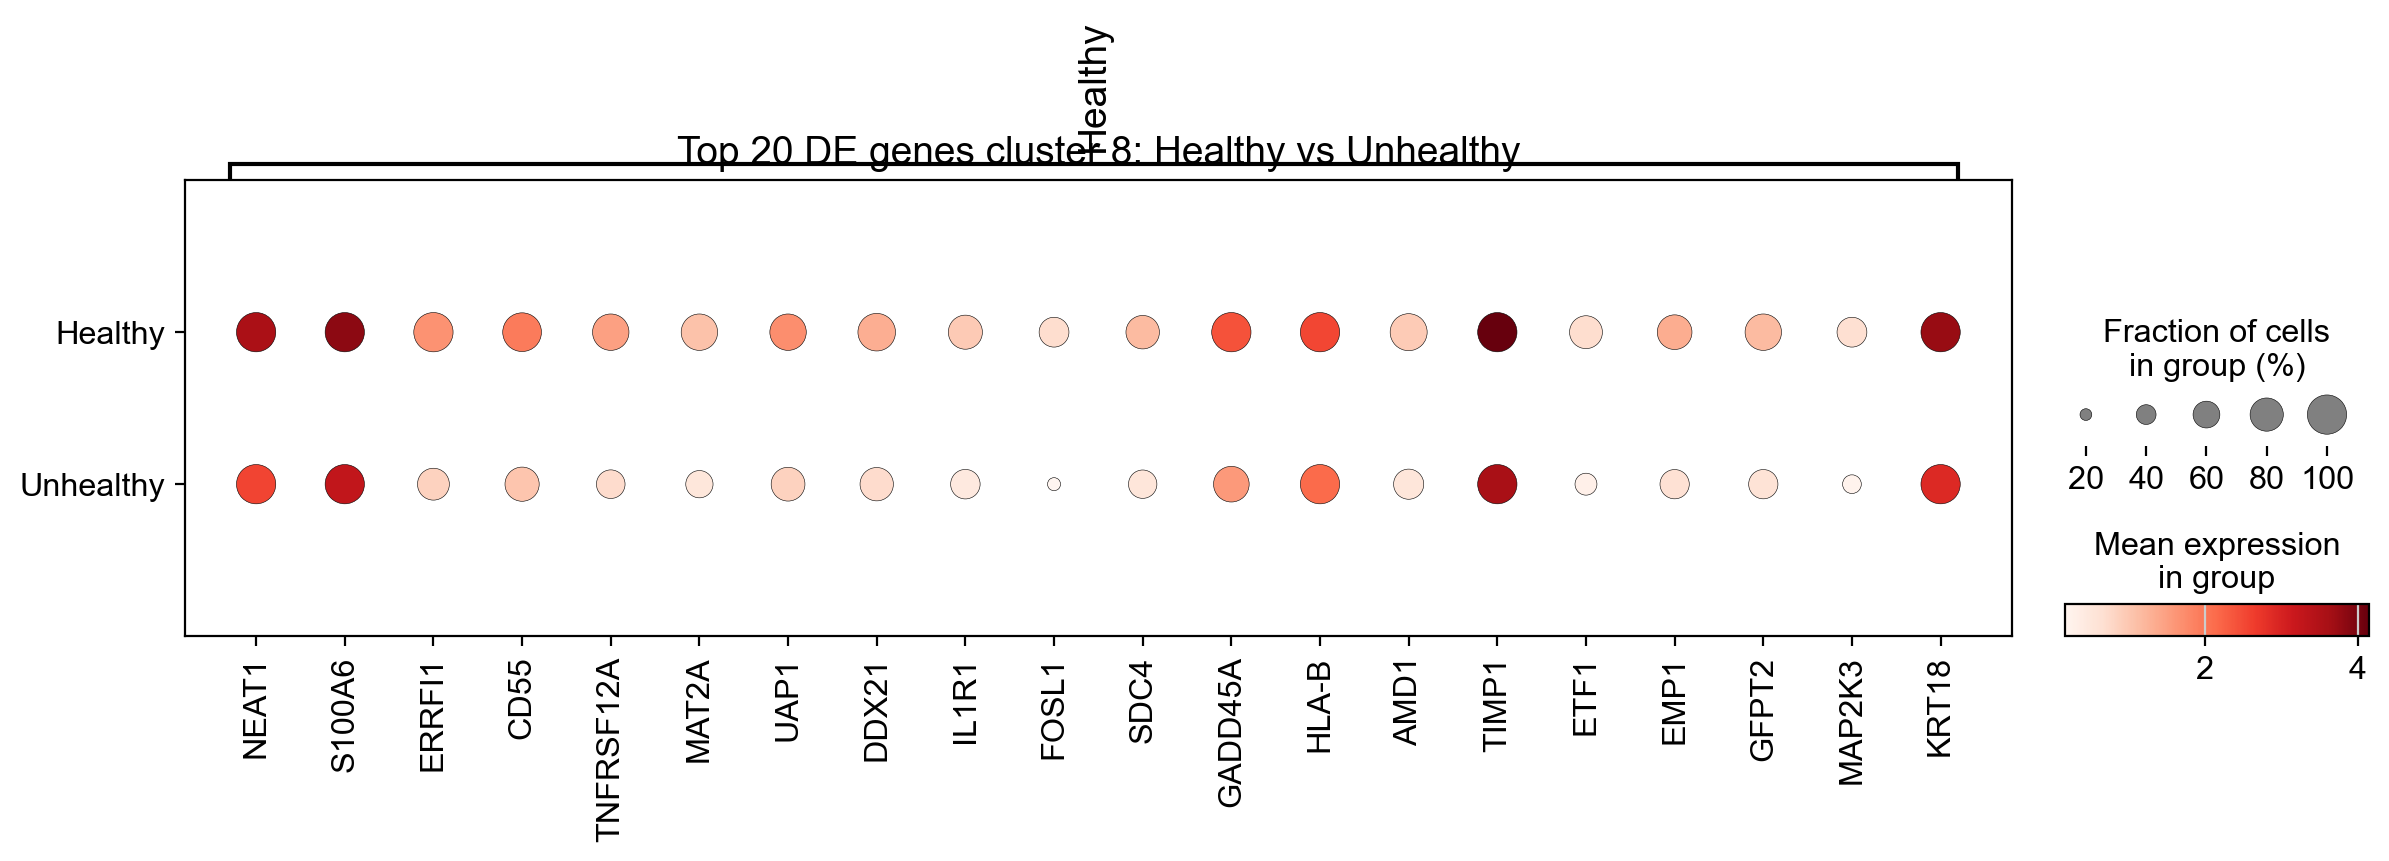

In [32]:
sc.pl.rank_genes_groups_dotplot(
    sub_c8,
    groupby='cohort',
    key='de_c8_healthy_vs_unhealthy',
    n_genes=20,
    title='Top 20 DE genes cluster 8: Healthy vs Unhealthy',
    figsize=(14, 3),
    save='_de_c8_healthy_vs_unhealthy.png',
)

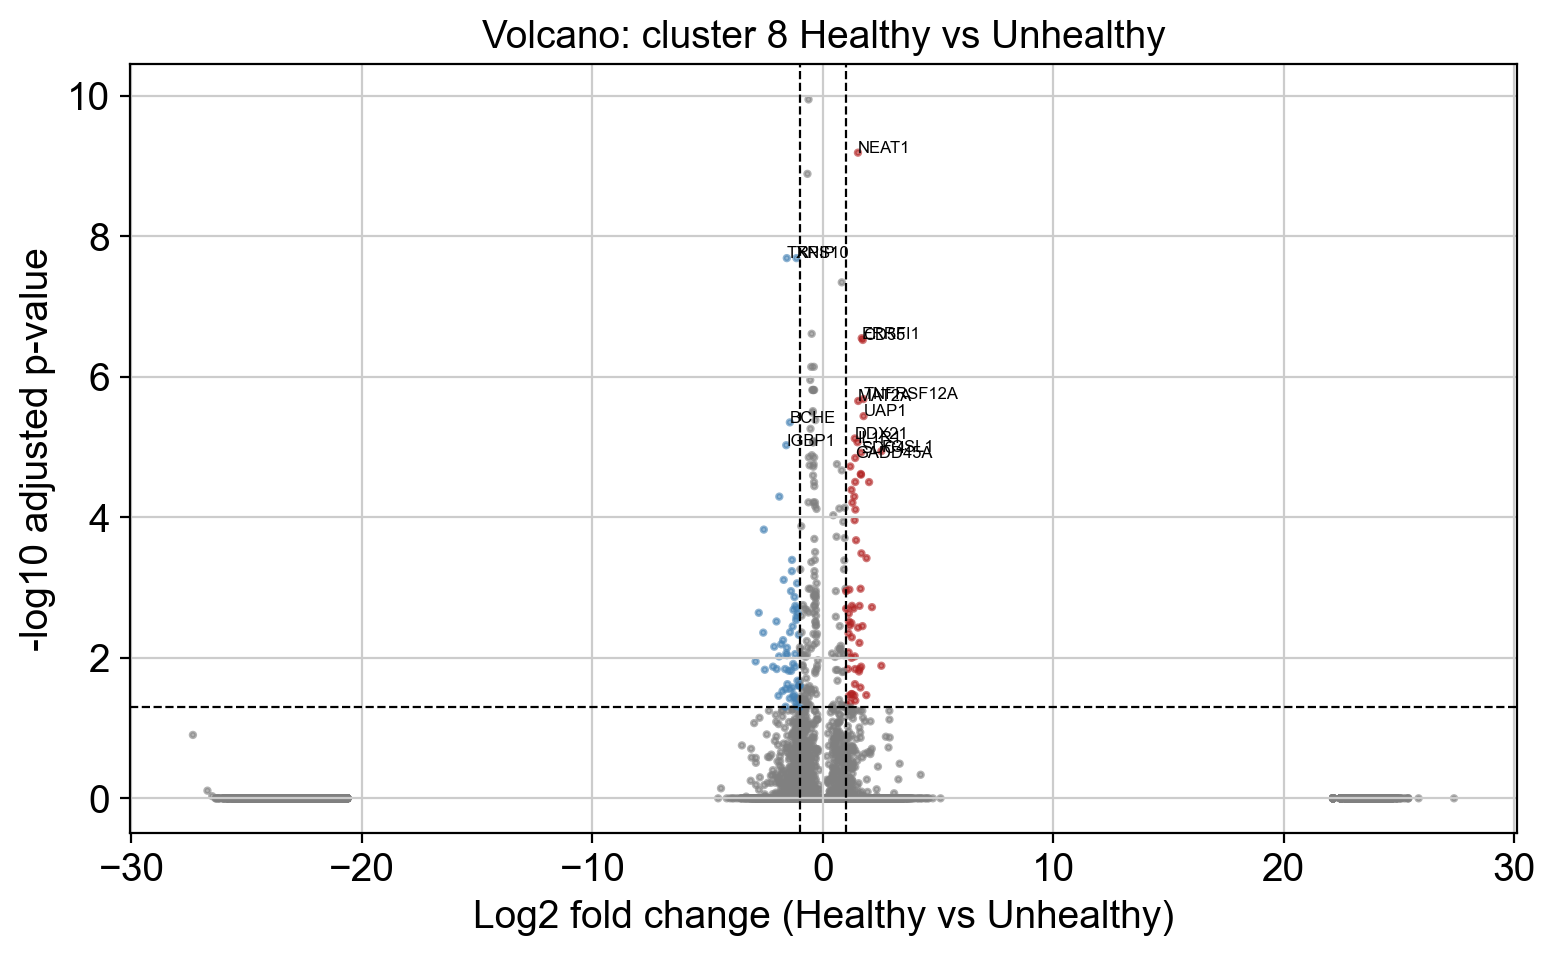

In [34]:
df8 = de_c8.copy()
df8['neg_log10_pval'] = -np.log10(df8['pvals_adj'].clip(1e-300))
df8['color'] = 'grey'
df8.loc[(df8['pvals_adj'] < 0.05) & (df8['logfoldchanges'] >  1), 'color'] = 'firebrick'
df8.loc[(df8['pvals_adj'] < 0.05) & (df8['logfoldchanges'] < -1), 'color'] = 'steelblue'

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df8['logfoldchanges'], df8['neg_log10_pval'], c=df8['color'], s=4, alpha=0.6)

for _, row in df8[df8['color'] != 'grey'].nlargest(15, 'neg_log10_pval').iterrows():
    ax.text(row['logfoldchanges'], row['neg_log10_pval'], row['names'], fontsize=6)

ax.axhline(-np.log10(0.05), color='k', lw=0.8, ls='--')
ax.axvline(1,  color='k', lw=0.8, ls='--')
ax.axvline(-1, color='k', lw=0.8, ls='--')
ax.set_xlabel('Log2 fold change (Healthy vs Unhealthy)')
ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano: cluster 8 Healthy vs Unhealthy')
plt.tight_layout()
plt.savefig('figures/volcano_de_c8_healthy_vs_unhealthy.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Save DE results to CSV
de_4_7_vs_1.to_csv('results/de_4_7_vs_1.csv', index=False)
de_c8.to_csv('results/de_c8_healthy_vs_unhealthy.csv', index=False)
print('Saved.')

Saved.


## DE within cluster 6: Healthy vs Unhealthy

In [37]:
sub_c6 = sub[sub.obs['leiden'] == '6'].copy()
print(f"Cluster 6 cells: {sub_c6.n_obs}")
print(sub_c6.obs.value_counts(['cohort', "common_participant"]).sort_index())

Cluster 6 cells: 950
cohort     common_participant
Healthy    Healthy_0             202
           Healthy_1              41
           Healthy_2              14
           Healthy_3             146
Unhealthy  Unhealthy_0             6
           Unhealthy_1            62
           Unhealthy_2           137
           Unhealthy_3           305
           Unhealthy_4            37
Name: count, dtype: int64


In [38]:
sc.tl.rank_genes_groups(
    sub_c6,
    groupby='cohort',
    groups=['Healthy'],
    reference='Unhealthy',
    method='wilcoxon',
    key_added='de_c6_healthy_vs_unhealthy',
    pts=True,
)

de_c6 = sc.get.rank_genes_groups_df(
    sub_c6, group='Healthy', key='de_c6_healthy_vs_unhealthy'
).sort_values('scores', ascending=False)

print('Top upregulated in Healthy (cluster 6):')
print(de_c6.head(20).to_string(index=False))
print()
print('Top downregulated in Healthy / upregulated in Unhealthy (cluster 6):')
print(de_c6.tail(20).to_string(index=False))

Top upregulated in Healthy (cluster 6):
    names    scores  logfoldchanges        pvals    pvals_adj  pct_nz_group
     DDX5 10.974813        0.713493 5.051038e-28 6.606253e-24      0.942928
     LMNA 10.783052        1.113092 4.139159e-27 2.706803e-23      0.866005
     XIST 10.470711        2.396953 1.177559e-25 5.133765e-22      0.548387
  SPARCL1  9.986107        0.908782 1.753328e-23 5.277351e-20      0.977667
 MTRNR2L8  9.768029        1.388441 1.544262e-22 4.039479e-19      0.749380
   PHLDA1  9.550311        1.870327 1.293076e-21 3.074934e-18      0.657568
     SFPQ  9.168107        1.225333 4.813975e-20 8.994569e-17      0.717122
   EIF4A1  8.782554        0.581795 1.598041e-18 2.200083e-15      0.905707
    HSPA8  8.091716        0.771805 5.883003e-16 5.306469e-13      0.893300
     EMP1  8.036808        1.303789 9.220923e-16 7.780674e-13      0.694789
     VMP1  7.949720        1.089219 1.869332e-15 1.358277e-12      0.808933
     JUND  7.547778        0.388748 4.427462e-14

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15664/2307071572.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_dotplot(


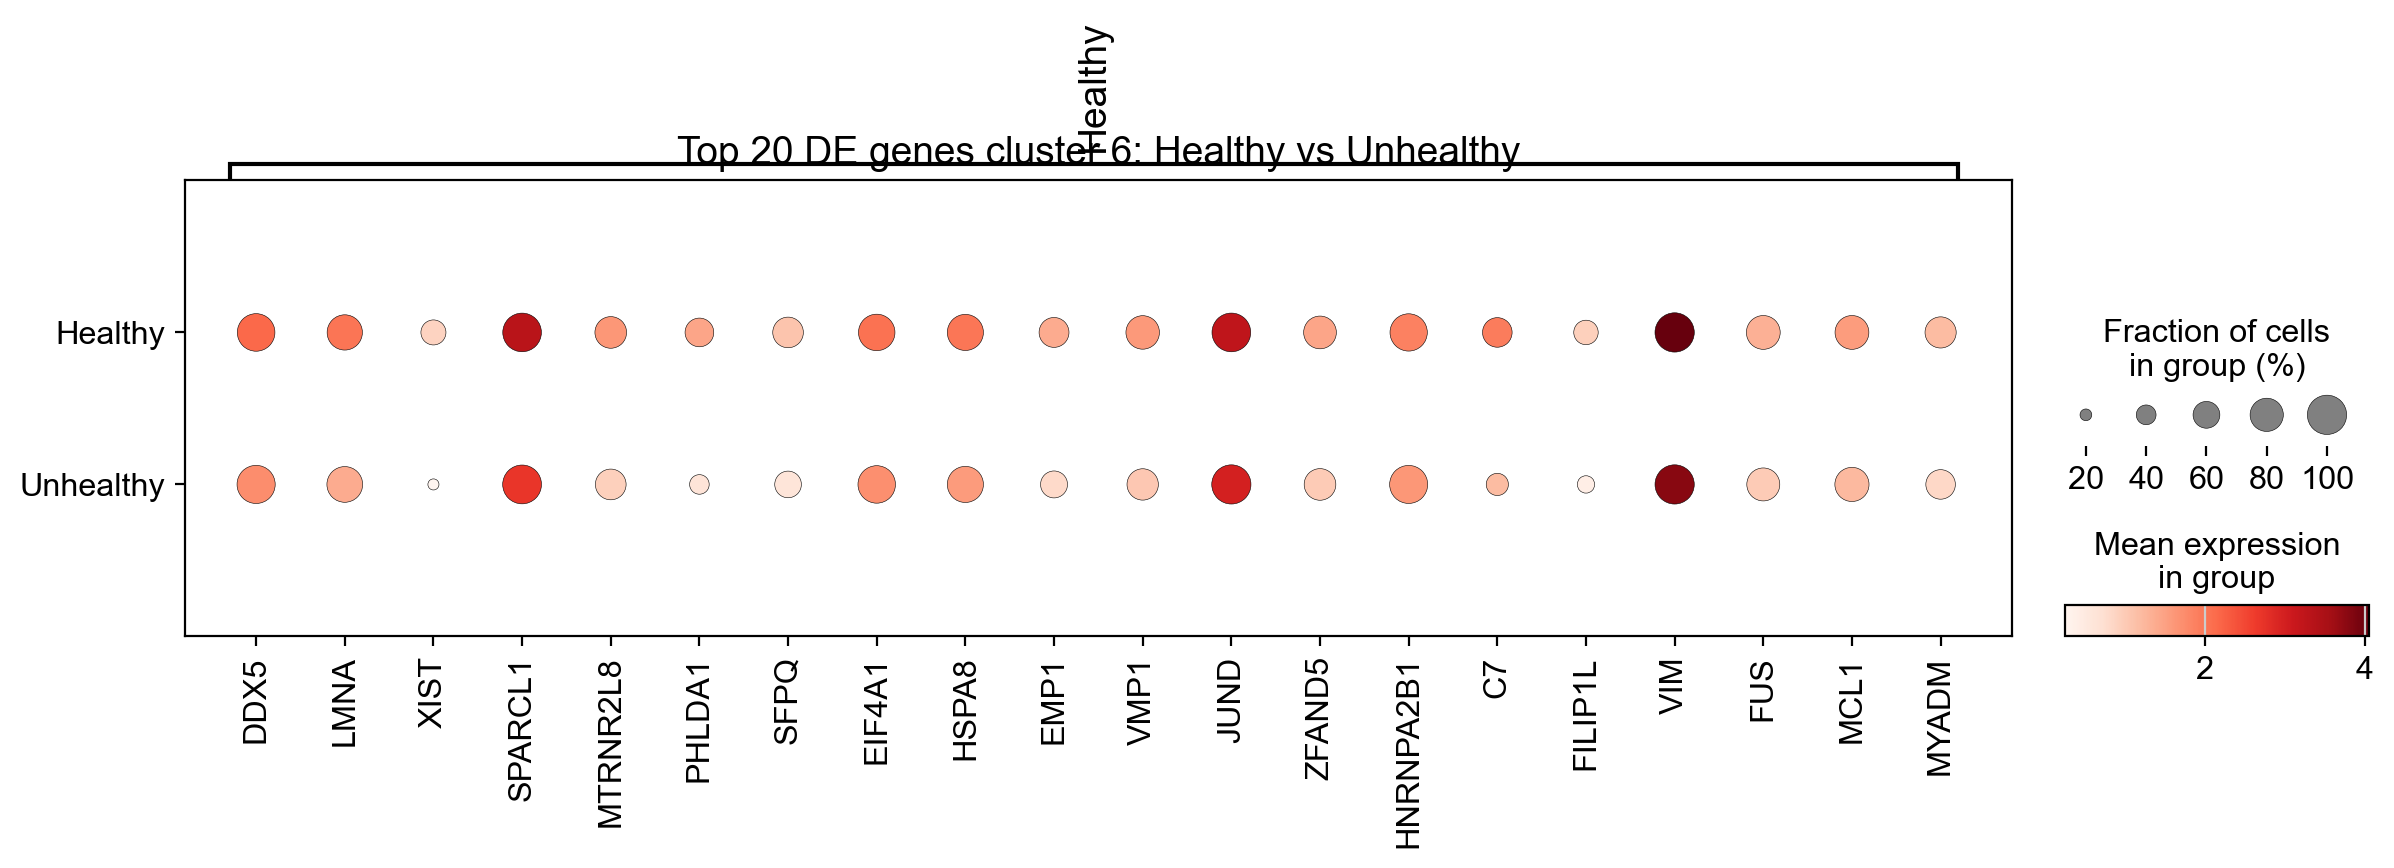

In [39]:
sc.pl.rank_genes_groups_dotplot(
    sub_c6,
    groupby='cohort',
    key='de_c6_healthy_vs_unhealthy',
    n_genes=20,
    title='Top 20 DE genes cluster 6: Healthy vs Unhealthy',
    figsize=(14, 3),
    save='_de_c6_healthy_vs_unhealthy.png',
)

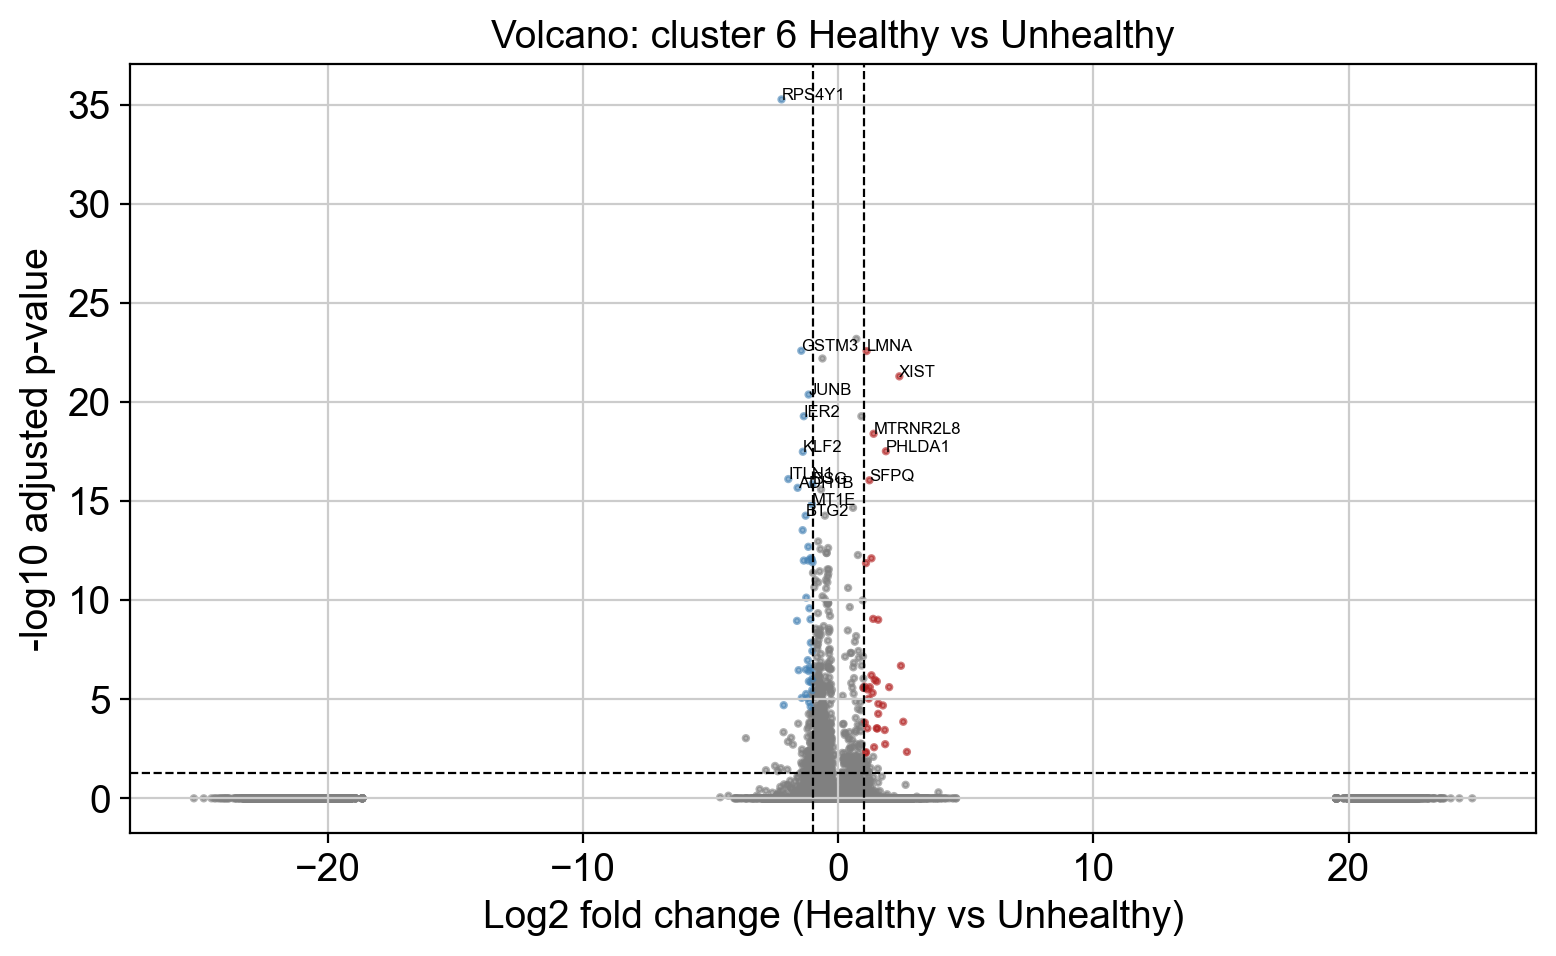

In [40]:
df6 = de_c6.copy()
df6['neg_log10_pval'] = -np.log10(df6['pvals_adj'].clip(1e-300))
df6['color'] = 'grey'
df6.loc[(df8['pvals_adj'] < 0.05) & (df6['logfoldchanges'] >  1), 'color'] = 'firebrick'
df6.loc[(df8['pvals_adj'] < 0.05) & (df6['logfoldchanges'] < -1), 'color'] = 'steelblue'

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df6['logfoldchanges'], df6['neg_log10_pval'], c=df6['color'], s=4, alpha=0.6)

for _, row in df6[df6['color'] != 'grey'].nlargest(15, 'neg_log10_pval').iterrows():
    ax.text(row['logfoldchanges'], row['neg_log10_pval'], row['names'], fontsize=6)

ax.axhline(-np.log10(0.05), color='k', lw=0.8, ls='--')
ax.axvline(1,  color='k', lw=0.8, ls='--')
ax.axvline(-1, color='k', lw=0.8, ls='--')
ax.set_xlabel('Log2 fold change (Healthy vs Unhealthy)')
ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano: cluster 6 Healthy vs Unhealthy')
plt.tight_layout()
plt.savefig('figures/volcano_de_c6_healthy_vs_unhealthy.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Save DE results to CSV
de_c6.to_csv('results/de_c6_healthy_vs_unhealthy.csv', index=False)
print('Saved.')

Saved.
